Using torch device: cpu

=== BB84 EAVESDROPPING / CLONING (IDENTITY INIT ONLY) ===
         Method  Final Fidelity (ideal)  Fidelity (shots=1000)  Fidelity (noisy)
convex baseline                0.608442                0.61150          0.602384
    Multi-stage                0.853546                0.85450          0.836355
      nonconvex                0.792705                0.79375          0.778473

Reference PCCM fidelity: 0.8535533905932737


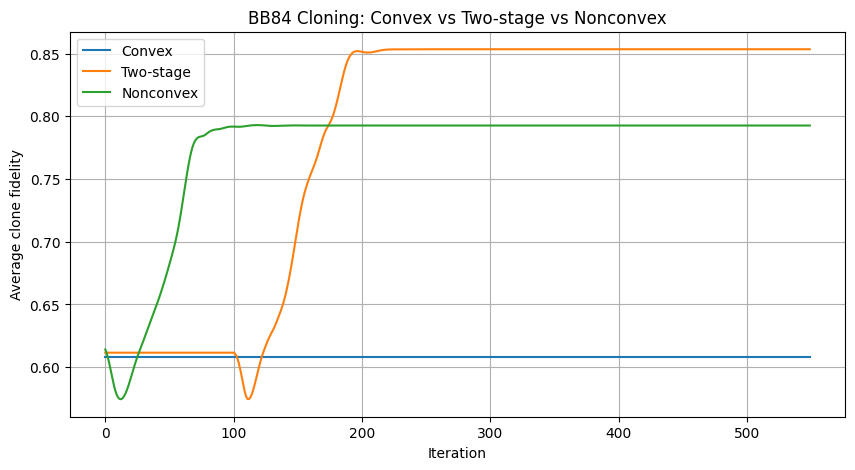

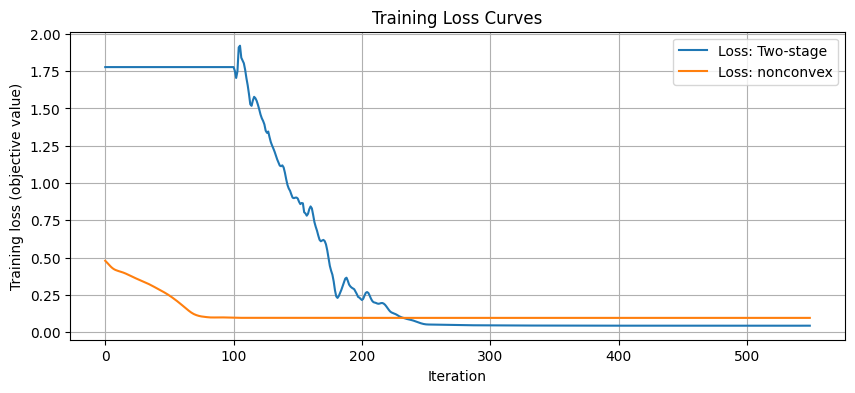

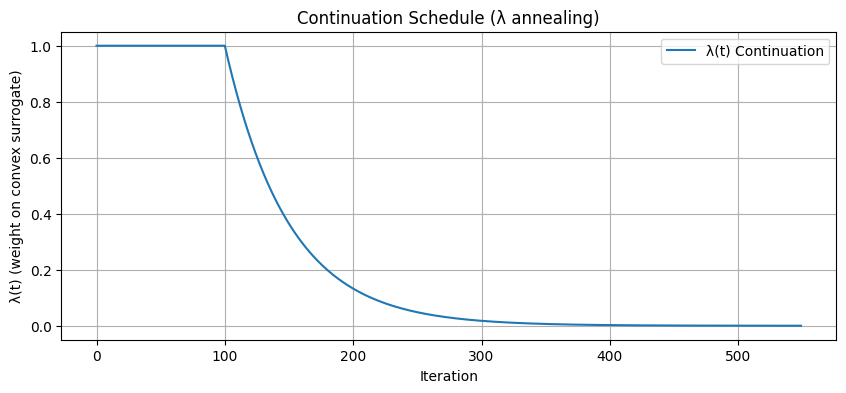

In [55]:
# ============================================================
# BB84 Eavesdropping / Approximate Cloning with PQC-3 (10 Qubits)
#
# Compare (IDENTITY INIT ONLY):
#   (0) Ridge-linearized init (convex ridge QP in Δw) — ridge-only (no training)
#   (1) Multi-stage "convex → nonconvex" continuation — identity init + training
#   (2) Direct nonconvex square-loss training          — identity init + training
#
# Notes:
# - ONE measurement per QNode, no arithmetic inside QNode
# - Fidelity via basis overlap trick:
#     F = (1 + <Z>)/2 after applying adjoint(StatePrep(|ψ>)) on clone wire
# - Hardware-friendly gates: RX, RZ, CNOT
#
# Author: Francis Boabang
# ============================================================

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

# ----------------------------
# Global setup
# ----------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device_torch = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using torch device:", device_torch)

# ============================================================
# 1) BB84 states (single-qubit)
# ============================================================

bb84_states = {
    "0": torch.tensor([1.0, 0.0], dtype=torch.complex64),
    "1": torch.tensor([0.0, 1.0], dtype=torch.complex64),
    "+": torch.tensor([1.0, 1.0], dtype=torch.complex64) / np.sqrt(2),
    "-": torch.tensor([1.0, -1.0], dtype=torch.complex64) / np.sqrt(2),
}
labels = list(bb84_states.keys())


def pccm_fidelity():
    # phase-covariant cloner bound (reference)
    return 0.8535533905932737


# ============================================================
# 2) System: 10 qubits
# ============================================================

N_QUBITS = 10
ALICE = 0
BOB = 1
EVE = 2

# ============================================================
# 3) Devices
# ============================================================

SHOTS = 1000
dev_analytic = qml.device("default.qubit", wires=N_QUBITS, shots=None)
dev_shots = qml.device("default.qubit", wires=N_QUBITS, shots=SHOTS)
dev_noisy = qml.device("default.mixed", wires=N_QUBITS)

# ============================================================
# 4) PQC-3 ansatz: RX, RZ, CNOT
# ============================================================

N_LAYERS = 5
N_PARAMS = 2 * N_LAYERS * N_QUBITS


def pqc3_ansatz(weights: torch.Tensor, entangle: bool = True):
    """
    weights shape: (N_PARAMS,)
    """
    idx = 0
    for _ in range(N_LAYERS):
        for q in range(N_QUBITS):
            qml.RX(weights[idx], wires=q)
            idx += 1
            qml.RZ(weights[idx], wires=q)
            idx += 1
        if entangle:
            for q in range(N_QUBITS - 1):
                qml.CNOT(wires=[q, q + 1])
            qml.CNOT(wires=[N_QUBITS - 1, 0])


def _prepare(
    state: torch.Tensor,
    weights: torch.Tensor,
    entangle: bool = True,
    noisy: bool = False,
    p_dep: float = 0.02,
    gamma: float = 0.03,
):
    # Encode BB84 state on ALICE
    qml.StatePrep(state, wires=ALICE)

    # Global unitary (acts like Eve's cloning / interaction circuit)
    pqc3_ansatz(weights, entangle=entangle)

    if noisy:
        for q in range(N_QUBITS):
            qml.DepolarizingChannel(p_dep, wires=q)
        for q in range(N_QUBITS):
            qml.AmplitudeDamping(gamma, wires=q)


# ============================================================
# 5) QNodes: return raw <Z> only
# ============================================================

@qml.qnode(dev_analytic, interface="torch", diff_method="backprop")
def z_bob_ideal(state, weights, entangle=True):
    _prepare(state, weights, entangle=entangle, noisy=False)
    qml.adjoint(qml.StatePrep)(state, wires=BOB)
    return qml.expval(qml.PauliZ(BOB))


@qml.qnode(dev_analytic, interface="torch", diff_method="backprop")
def z_eve_ideal(state, weights, entangle=True):
    _prepare(state, weights, entangle=entangle, noisy=False)
    qml.adjoint(qml.StatePrep)(state, wires=EVE)
    return qml.expval(qml.PauliZ(EVE))


@qml.qnode(dev_shots, interface="torch")
def z_bob_shots(state, weights):
    _prepare(state, weights, entangle=True, noisy=False)
    qml.adjoint(qml.StatePrep)(state, wires=BOB)
    return qml.expval(qml.PauliZ(BOB))


@qml.qnode(dev_shots, interface="torch")
def z_eve_shots(state, weights):
    _prepare(state, weights, entangle=True, noisy=False)
    qml.adjoint(qml.StatePrep)(state, wires=EVE)
    return qml.expval(qml.PauliZ(EVE))


@qml.qnode(dev_noisy, interface="torch", diff_method="backprop")
def z_bob_noisy(state, weights, p_dep=0.02, gamma=0.03):
    _prepare(state, weights, entangle=True, noisy=True, p_dep=p_dep, gamma=gamma)
    qml.adjoint(qml.StatePrep)(state, wires=BOB)
    return qml.expval(qml.PauliZ(BOB))


@qml.qnode(dev_noisy, interface="torch", diff_method="backprop")
def z_eve_noisy(state, weights, p_dep=0.02, gamma=0.03):
    _prepare(state, weights, entangle=True, noisy=True, p_dep=p_dep, gamma=gamma)
    qml.adjoint(qml.StatePrep)(state, wires=EVE)
    return qml.expval(qml.PauliZ(EVE))


def z_to_fidelity(Z):
    return 0.5 * (1.0 + Z)


# ============================================================
# 6) Metrics + losses
# ============================================================

def avg_clone_fidelity(weights, entangle=True):
    vals = []
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_ideal(st, weights, entangle=entangle)
        ZE = z_eve_ideal(st, weights, entangle=entangle)
        FB = z_to_fidelity(ZB)
        FE = z_to_fidelity(ZE)
        vals.append(0.5 * (FB + FE))
    return torch.stack(vals).mean()


def nonconvex_square_loss(weights, entangle=True, beta_sym=1.0):
    loss = 0.0
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_ideal(st, weights, entangle=entangle)
        ZE = z_eve_ideal(st, weights, entangle=entangle)
        FB = z_to_fidelity(ZB)
        FE = z_to_fidelity(ZE)
        loss = loss + (1.0 - FB) ** 2 + (1.0 - FE) ** 2
        # Optional symmetry regularizer:
        # loss = loss + beta_sym * (FB - FE)**2
    return loss / len(labels)


def convex_square_surrogate(weights, entangle=True):
    # Convex-ish surrogate in Z-space (still nonconvex in weights, but smoother & easier early)
    loss = 0.0
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_ideal(st, weights, entangle=entangle)
        ZE = z_eve_ideal(st, weights, entangle=entangle)
        loss = loss + (1.0 - ZB) ** 2 + (1.0 - ZE) ** 2
    return loss / len(labels)


# ============================================================
# 7) Initializer (IDENTITY-BIASED ONLY) + ridge-linearized step
# ============================================================

def init_identity_biased(eps=0.03):
    scale = eps / np.sqrt(N_QUBITS)
    w = scale * torch.randn(N_PARAMS)
    w.requires_grad_(True)
    return w

def init_random(std=0.1):
    """
    Standard random initialization for PQC parameters.
    No identity bias.
    """
    w = std * torch.randn(N_PARAMS)
    w.requires_grad_(True)
    return w

def ridge_linearized_init(
    w0: torch.Tensor,
    entangle: bool = True,
    lam: float = 1e-2,
    target_z: float = 1.0,
):
    """
    Convex ridge step in Δw using a first-order linearization:

      For each label l:
        ZB(w) ≈ ZB0 + (∇ZB0)^T Δw
        ZE(w) ≈ ZE0 + (∇ZE0)^T Δw

      Stack into Φ Δw ≈ r, where r = target_z - Z0,
      then solve ridge:
        Δw* = argmin ||ΦΔw - r||^2 + lam||Δw||^2

    Returns: w_init = (w0 + Δw*).detach().requires_grad_(True)
    """
    if not w0.requires_grad:
        w0.requires_grad_(True)

    Phi_rows = []
    r_rows = []

    for l in labels:
        st = bb84_states[l]

        # Bob
        ZB0 = z_bob_ideal(st, w0, entangle=entangle)
        gB = torch.autograd.grad(ZB0, w0, retain_graph=True, create_graph=False)[0]
        Phi_rows.append(gB.detach())
        r_rows.append((target_z - ZB0.detach()))

        # Eve
        ZE0 = z_eve_ideal(st, w0, entangle=entangle)
        gE = torch.autograd.grad(ZE0, w0, retain_graph=True, create_graph=False)[0]
        Phi_rows.append(gE.detach())
        r_rows.append((target_z - ZE0.detach()))

    Phi = torch.stack(Phi_rows, dim=0)  # (M, N_PARAMS)
    r = torch.stack(r_rows, dim=0)      # (M,)

    # Solve ridge in double for stability:
    Phi_d = Phi.to(dtype=torch.float64)
    r_d = r.to(dtype=torch.float64)

    A = Phi_d.T @ Phi_d + lam * torch.eye(N_PARAMS, dtype=torch.float64)
    b = Phi_d.T @ r_d
    delta = torch.linalg.solve(A, b).to(dtype=w0.dtype)

    w_init = (w0.detach() + delta.detach()).requires_grad_(True)
    return w_init


# ============================================================
# 8) Training: direct vs multi-stage continuation
# ============================================================

def train_direct_nonconvex(w, steps=350, lr=0.02, beta_sym=1.0):
    opt = torch.optim.Adam([w], lr=lr)
    hist_fid, hist_loss = [], []
    for _ in range(steps):
        opt.zero_grad()
        L = nonconvex_square_loss(w, entangle=True, beta_sym=beta_sym)
        L.backward()
        opt.step()
        with torch.no_grad():
            hist_loss.append(L.item())
            hist_fid.append(avg_clone_fidelity(w).item())
    return hist_fid, hist_loss


def train_multistage_convex_to_nonconvex(
    w,
    stage1_steps=200,
    stage2_steps=350,
    lr=0.02,
    beta_sym=1.0,
    lam0=0.5,
    lam_decay=0.98,
):
    opt = torch.optim.Adam([w], lr=lr)
    hist_fid, hist_loss, lam_hist = [], [], []

    # ---- Stage 1: surrogate only ----
    for _ in range(stage1_steps):
        opt.zero_grad()
        w_ridge = ridge_linearized_init(w, entangle=True, lam=1e-2, target_z=1.0)
        Lcx = convex_square_surrogate(w_ridge, entangle=True)
        Lcx.backward()
        opt.step()
        with torch.no_grad():
            hist_loss.append(Lcx.item())
            hist_fid.append(avg_clone_fidelity(w).item())
            lam_hist.append(1.0)

    # ---- Stage 2: annealed mixture ----
    lam = lam0
    for _ in range(stage2_steps):
        opt.zero_grad()
        w_ridge = ridge_linearized_init(w, entangle=True, lam=1e-2, target_z=1.0)
        Lcx = convex_square_surrogate(w_ridge, entangle=True)
        Lnc = nonconvex_square_loss(w, entangle=True, beta_sym=beta_sym)
        L = (1.0 - lam) * Lnc + lam * Lcx
        L.backward()
        opt.step()
        with torch.no_grad():
            hist_loss.append(L.item())
            hist_fid.append(avg_clone_fidelity(w).item())
            lam_hist.append(lam)
        lam = max(0.0, lam * lam_decay)

    return hist_fid, hist_loss, lam_hist



def train_multistage_convex_to_nonconvex_edited(
    w,
    stage1_steps=200,
    stage2_steps=350,
    lr=0.02,
    beta_sym=1.0,
    lam0=0.5,
    lam_decay=0.98,
    eta_cx=0.1,   # convex inner-step size
):
    """
    Multi-stage optimization:
      Stage 1: pure convex surrogate
      Stage 2: convex → nonconvex continuation
               (nonconvex evaluated at convex-updated weights)

    Fully differentiable and PyTorch-safe.
    """
    opt = torch.optim.Adam([w], lr=lr)
    hist_fid, hist_loss, lam_hist = [], [], []

    # --------------------------------------------------
    # Stage 1: convex surrogate only
    # --------------------------------------------------
    for _ in range(stage1_steps):
        opt.zero_grad()
        w_ridge = ridge_linearized_init(w, entangle=True, lam=1e-2, target_z=1.0)
        Lcx = convex_square_surrogate(w_ridge, entangle=True)
        Lcx.backward()
        opt.step()

        with torch.no_grad():
            hist_loss.append(Lcx.item())
            hist_fid.append(avg_clone_fidelity(w_ridge).item())
            lam_hist.append(1.0)

    # --------------------------------------------------
    # Stage 2: convex → nonconvex continuation
    # --------------------------------------------------
    lam = lam0
    for _ in range(stage2_steps):
        opt.zero_grad()

        # ---- convex surrogate ----
        w_ridge = ridge_linearized_init(w, entangle=True, lam=1e-2, target_z=1.0)
        Lcx = convex_square_surrogate(w_ridge, entangle=True)

        # ---- convex-guided parameter update ----
        g_cx = torch.autograd.grad(
            Lcx, w, create_graph=True
        )[0]

        # IMPORTANT: no detach — allow gradient flow
        w_cx = w - eta_cx * g_cx

        # ---- nonconvex loss evaluated at w_cx ----
        Lnc = nonconvex_square_loss(
            w_cx, entangle=True, beta_sym=beta_sym
        )

        # ---- continuation objective ----
        L = (1.0 - lam) * Lnc + lam * Lcx
        L.backward()
        opt.step()

        with torch.no_grad():
            hist_loss.append(L.item())
            hist_fid.append(avg_clone_fidelity(w).item())
            lam_hist.append(lam)

        lam = max(0.0, lam * lam_decay)

    return hist_fid, hist_loss, lam_hist



# ============================================================
# 9) Noise evaluation
# ============================================================

def eval_noise(w, p_dep=0.02, gamma=0.03):
    # shots
    FBs, FEs = [], []
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_shots(st, w)
        ZE = z_eve_shots(st, w)
        FBs.append(z_to_fidelity(ZB))
        FEs.append(z_to_fidelity(ZE))
    F_shots = 0.5 * (torch.stack(FBs).mean() + torch.stack(FEs).mean()).item()

    # noisy channels
    FBn, FEn = [], []
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_noisy(st, w, p_dep=p_dep, gamma=gamma)
        ZE = z_eve_noisy(st, w, p_dep=p_dep, gamma=gamma)
        FBn.append(z_to_fidelity(ZB))
        FEn.append(z_to_fidelity(ZE))
    F_noisy = 0.5 * (torch.stack(FBn).mean() + torch.stack(FEn).mean()).item()

    return F_shots, F_noisy


# ============================================================
# 10) Run comparisons (IDENTITY INIT ONLY)
# ============================================================

STAGE1 = 100 #20
STAGE2 = 450
DIRECT = 550

LR = 0.02
BETA_SYM = 1.0

# (0) Ridge-only baseline: identity init + convex ridge step, then evaluate (no training)
w_0 = init_random(std=0.1)
#w_ridge = ridge_linearized_init(w_0, entangle=True, lam=1e-2, target_z=1.0)
#with torch.no_grad():
 #   fid_ridge_ideal = avg_clone_fidelity(w_ridge).item()
#F_ridge_shots, F_ridge_noisy = eval_noise(w_ridge.detach())
fid_ridge_ideal, loss_ridge, lam_ridge = train_multistage_convex_to_nonconvex(
    w_0,
    stage1_steps=550,
    stage2_steps=0,
    lr=LR,
    beta_sym=BETA_SYM,
    lam0=1,
    lam_decay=0.98,
)
F_ridge_shots, F_ridge_noisy = eval_noise(w_0.detach())

# (1) Multi-stage continuation: identity init + training
w_ms = init_random(std=0.1)
fid_ms, loss_ms, lam_ms = train_multistage_convex_to_nonconvex(
    w_ms,
    stage1_steps=100,
    stage2_steps=450,
    lr=LR,
    beta_sym=BETA_SYM,
    lam0=1,
    lam_decay=0.98,
)
F_ms_shots, F_ms_noisy = eval_noise(w_ms.detach())

# (2) Direct nonconvex: identity init + training
w_dc = init_random(std=0.1)
fid_dc, loss_dc = train_direct_nonconvex(
    w_dc, steps=DIRECT, lr=LR, beta_sym=BETA_SYM
)
F_dc_shots, F_dc_noisy = eval_noise(w_dc.detach())

# ============================================================
# 11) Summary table
# ============================================================

summary = pd.DataFrame({
    "Method": [
        "convex baseline",
        "Multi-stage",
        "nonconvex",
    ],
    "Final Fidelity (ideal)": [
        float(fid_ridge_ideal[-1]),
        float(fid_ms[-1]),
        float(fid_dc[-1]),
    ],
    f"Fidelity (shots={SHOTS})": [
        float(F_ridge_shots),
        float(F_ms_shots),
        float(F_dc_shots),
    ],
    "Fidelity (noisy)": [
        float(F_ridge_noisy),
        float(F_ms_noisy),
        float(F_dc_noisy),
    ],
})

print("\n=== BB84 EAVESDROPPING / CLONING (IDENTITY INIT ONLY) ===")
print(summary.to_string(index=False))
print("\nReference PCCM fidelity:", pccm_fidelity())

# ============================================================
# 12) Publication-ready plots
# ============================================================

# --- Fidelity curves (ridge is a constant baseline) ---
plt.figure(figsize=(10, 5))
plt.plot(fid_ridge_ideal, label="Convex")
plt.plot(fid_ms, label="Two-stage ")
plt.plot(fid_dc, label="Nonconvex")
plt.xlabel("Iteration")
plt.ylabel("Average clone fidelity")
plt.title("BB84 Cloning: Convex vs Two-stage vs Nonconvex")
plt.grid(True)
plt.legend()
plt.show()

# --- Loss curves (only for trained methods) ---
plt.figure(figsize=(10, 4))
plt.plot(loss_ms, label="Loss: Two-stage")
plt.plot(loss_dc, label="Loss: nonconvex")
plt.xlabel("Iteration")
plt.ylabel("Training loss (objective value)")
plt.title("Training Loss Curves")
plt.grid(True)
plt.legend()
plt.show()

# --- Lambda schedule (only for continuation) ---
plt.figure(figsize=(10, 4))
plt.plot(lam_ms, label="λ(t) Continuation")
plt.xlabel("Iteration")
plt.ylabel("λ(t) (weight on convex surrogate)")
plt.title("Continuation Schedule (λ annealing)")
plt.grid(True)
plt.legend()
plt.show()


Using torch device: cpu

=== Running for N_LAYERS = 1 (N_QUBITS = 10) ===


/Users/boabangfrancis/anaconda3/lib/python3.11/site-packages/pennylane/devices/device_api.py:193: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(



=== Running for N_LAYERS = 2 (N_QUBITS = 10) ===

=== Running for N_LAYERS = 3 (N_QUBITS = 10) ===

=== Running for N_LAYERS = 4 (N_QUBITS = 10) ===

=== Running for N_LAYERS = 5 (N_QUBITS = 10) ===

=== Running for N_LAYERS = 6 (N_QUBITS = 10) ===

=== Running for N_LAYERS = 7 (N_QUBITS = 10) ===

=== Running for N_LAYERS = 8 (N_QUBITS = 10) ===

=== Running for N_LAYERS = 9 (N_QUBITS = 10) ===

=== Running for N_LAYERS = 10 (N_QUBITS = 10) ===

=== FIXED QUBITS (N_QUBITS = 10), VARYING LAYERS ===
 Layers  Convex (ideal)  Convex (shots)  Convex (noisy)  Two-stage (ideal)  Two-stage (shots)  Two-stage (noisy)  Nonconvex (ideal)  Nonconvex (shots)  Nonconvex (noisy)
      1        0.744027        0.747500        0.730394           0.750000           0.751125           0.736033           0.750000           0.753125           0.736033
      2        0.609853        0.607250        0.603716           0.625000           0.618500           0.618017           0.625000           0.617000     

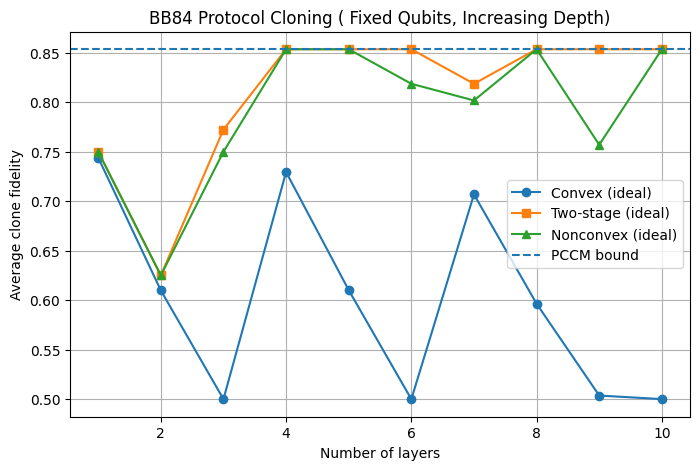

In [72]:



# ============================================================
# BB84 Eavesdropping / Approximate Cloning with PQC-3 (10 Qubits)
#
# Compare (IDENTITY INIT ONLY):
#   (0) Ridge-linearized init (convex ridge QP in Δw) — ridge-only (no training)
#   (1) Multi-stage "convex → nonconvex" continuation — identity init + training
#   (2) Direct nonconvex square-loss training          — identity init + training
#
# Notes:
# - ONE measurement per QNode, no arithmetic inside QNode
# - Fidelity via basis overlap trick:
#     F = (1 + <Z>)/2 after applying adjoint(StatePrep(|ψ>)) on clone wire
# - Hardware-friendly gates: RX, RZ, CNOT
#
# Author: Francis Boabang
# ============================================================

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

# ----------------------------
# Global setup
# ----------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device_torch = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using torch device:", device_torch)

# ============================================================
# 1) BB84 states (single-qubit)
# ============================================================

bb84_states = {
    "0": torch.tensor([1.0, 0.0], dtype=torch.complex64),
    "1": torch.tensor([0.0, 1.0], dtype=torch.complex64),
    "+": torch.tensor([1.0, 1.0], dtype=torch.complex64) / np.sqrt(2),
    "-": torch.tensor([1.0, -1.0], dtype=torch.complex64) / np.sqrt(2),
}
labels = list(bb84_states.keys())


def pccm_fidelity():
    # phase-covariant cloner bound (reference)
    return 0.8535533905932737


# ============================================================
# 2) System: 10 qubits
# ============================================================

N_QUBITS = 10
ALICE = 0
BOB = 1
EVE = 2

# ============================================================
# 3) Devices
# ============================================================

SHOTS = 1000
dev_analytic = qml.device("default.qubit", wires=N_QUBITS, shots=None)
dev_shots = qml.device("default.qubit", wires=N_QUBITS, shots=SHOTS)
dev_noisy = qml.device("default.mixed", wires=N_QUBITS)

# ============================================================
# 4) PQC-3 ansatz: RX, RZ, CNOT
# ============================================================

#N_LAYERS = 7
#N_PARAMS = 2 * N_LAYERS * N_QUBITS


def pqc3_ansatz(weights: torch.Tensor, entangle: bool = True):
    """
    weights shape: (N_PARAMS,)
    """
    idx = 0
    for _ in range(N_LAYERS):
        for q in range(N_QUBITS):
            qml.RX(weights[idx], wires=q)
            idx += 1
            qml.RZ(weights[idx], wires=q)
            idx += 1
        if entangle:
            for q in range(N_QUBITS - 1):
                qml.CNOT(wires=[q, q + 1])
            qml.CNOT(wires=[N_QUBITS - 1, 0])


def _prepare(
    state: torch.Tensor,
    weights: torch.Tensor,
    entangle: bool = True,
    noisy: bool = False,
    p_dep: float = 0.02,
    gamma: float = 0.03,
):
    # Encode BB84 state on ALICE
    qml.StatePrep(state, wires=ALICE)

    # Global unitary (acts like Eve's cloning / interaction circuit)
    pqc3_ansatz(weights, entangle=entangle)

    if noisy:
        for q in range(N_QUBITS):
            qml.DepolarizingChannel(p_dep, wires=q)
        for q in range(N_QUBITS):
            qml.AmplitudeDamping(gamma, wires=q)


# ============================================================
# 5) QNodes: return raw <Z> only
# ============================================================

@qml.qnode(dev_analytic, interface="torch", diff_method="backprop")
def z_bob_ideal(state, weights, entangle=True):
    _prepare(state, weights, entangle=entangle, noisy=False)
    qml.adjoint(qml.StatePrep)(state, wires=BOB)
    return qml.expval(qml.PauliZ(BOB))


@qml.qnode(dev_analytic, interface="torch", diff_method="backprop")
def z_eve_ideal(state, weights, entangle=True):
    _prepare(state, weights, entangle=entangle, noisy=False)
    qml.adjoint(qml.StatePrep)(state, wires=EVE)
    return qml.expval(qml.PauliZ(EVE))


@qml.qnode(dev_shots, interface="torch")
def z_bob_shots(state, weights):
    _prepare(state, weights, entangle=True, noisy=False)
    qml.adjoint(qml.StatePrep)(state, wires=BOB)
    return qml.expval(qml.PauliZ(BOB))


@qml.qnode(dev_shots, interface="torch")
def z_eve_shots(state, weights):
    _prepare(state, weights, entangle=True, noisy=False)
    qml.adjoint(qml.StatePrep)(state, wires=EVE)
    return qml.expval(qml.PauliZ(EVE))


@qml.qnode(dev_noisy, interface="torch", diff_method="backprop")
def z_bob_noisy(state, weights, p_dep=0.02, gamma=0.03):
    _prepare(state, weights, entangle=True, noisy=True, p_dep=p_dep, gamma=gamma)
    qml.adjoint(qml.StatePrep)(state, wires=BOB)
    return qml.expval(qml.PauliZ(BOB))


@qml.qnode(dev_noisy, interface="torch", diff_method="backprop")
def z_eve_noisy(state, weights, p_dep=0.02, gamma=0.03):
    _prepare(state, weights, entangle=True, noisy=True, p_dep=p_dep, gamma=gamma)
    qml.adjoint(qml.StatePrep)(state, wires=EVE)
    return qml.expval(qml.PauliZ(EVE))


def z_to_fidelity(Z):
    return 0.5 * (1.0 + Z)


# ============================================================
# 6) Metrics + losses
# ============================================================

def avg_clone_fidelity(weights, entangle=True):
    vals = []
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_ideal(st, weights, entangle=entangle)
        ZE = z_eve_ideal(st, weights, entangle=entangle)
        FB = z_to_fidelity(ZB)
        FE = z_to_fidelity(ZE)
        vals.append(0.5 * (FB + FE))
    return torch.stack(vals).mean()


def nonconvex_square_loss(weights, entangle=True, beta_sym=1.0):
    loss = 0.0
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_ideal(st, weights, entangle=entangle)
        ZE = z_eve_ideal(st, weights, entangle=entangle)
        FB = z_to_fidelity(ZB)
        FE = z_to_fidelity(ZE)
        loss = loss + (1.0 - FB) ** 2 + (1.0 - FE) ** 2
        # Optional symmetry regularizer:
        # loss = loss + beta_sym * (FB - FE)**2
    return loss / len(labels)


def convex_square_surrogate(weights, entangle=True):
    # Convex-ish surrogate in Z-space (still nonconvex in weights, but smoother & easier early)
    loss = 0.0
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_ideal(st, weights, entangle=entangle)
        ZE = z_eve_ideal(st, weights, entangle=entangle)
        loss = loss + (1.0 - ZB) ** 2 + (1.0 - ZE) ** 2
    return loss / len(labels)


# ============================================================
# 7) Initializer (IDENTITY-BIASED ONLY) + ridge-linearized step
# ============================================================

def init_identity_biased(eps=0.03):
    scale = eps / np.sqrt(N_QUBITS)
    w = scale * torch.randn(N_PARAMS)
    w.requires_grad_(True)
    return w

def init_random(std=0.1):
    """
    Standard random initialization for PQC parameters.
    No identity bias.
    """
    w = std * torch.randn(N_PARAMS)
    w.requires_grad_(True)
    return w

def ridge_linearized_init(
    w0: torch.Tensor,
    entangle: bool = True,
    lam: float = 1e-2,
    target_z: float = 1.0,
):
    """
    Convex ridge step in Δw using a first-order linearization:

      For each label l:
        ZB(w) ≈ ZB0 + (∇ZB0)^T Δw
        ZE(w) ≈ ZE0 + (∇ZE0)^T Δw

      Stack into Φ Δw ≈ r, where r = target_z - Z0,
      then solve ridge:
        Δw* = argmin ||ΦΔw - r||^2 + lam||Δw||^2

    Returns: w_init = (w0 + Δw*).detach().requires_grad_(True)
    """
    if not w0.requires_grad:
        w0.requires_grad_(True)

    Phi_rows = []
    r_rows = []

    for l in labels:
        st = bb84_states[l]

        # Bob
        ZB0 = z_bob_ideal(st, w0, entangle=entangle)
        gB = torch.autograd.grad(ZB0, w0, retain_graph=True, create_graph=False)[0]
        Phi_rows.append(gB.detach())
        r_rows.append((target_z - ZB0.detach()))

        # Eve
        ZE0 = z_eve_ideal(st, w0, entangle=entangle)
        gE = torch.autograd.grad(ZE0, w0, retain_graph=True, create_graph=False)[0]
        Phi_rows.append(gE.detach())
        r_rows.append((target_z - ZE0.detach()))

    Phi = torch.stack(Phi_rows, dim=0)  # (M, N_PARAMS)
    r = torch.stack(r_rows, dim=0)      # (M,)

    # Solve ridge in double for stability:
    Phi_d = Phi.to(dtype=torch.float64)
    r_d = r.to(dtype=torch.float64)

    A = Phi_d.T @ Phi_d + lam * torch.eye(N_PARAMS, dtype=torch.float64)
    b = Phi_d.T @ r_d
    delta = torch.linalg.solve(A, b).to(dtype=w0.dtype)

    w_init = (w0.detach() + delta.detach()).requires_grad_(True)
    return w_init


# ============================================================
# 8) Training: direct vs multi-stage continuation
# ============================================================

def train_direct_nonconvex(w, steps=350, lr=0.02, beta_sym=1.0):
    opt = torch.optim.Adam([w], lr=lr)
    hist_fid, hist_loss = [], []
    for _ in range(steps):
        opt.zero_grad()
        L = nonconvex_square_loss(w, entangle=True, beta_sym=beta_sym)
        L.backward()
        opt.step()
        with torch.no_grad():
            hist_loss.append(L.item())
            hist_fid.append(avg_clone_fidelity(w).item())
    return hist_fid, hist_loss


def train_multistage_convex_to_nonconvex(
    w,
    stage1_steps=200,
    stage2_steps=350,
    lr=0.02,
    beta_sym=1.0,
    lam0=0.5,
    lam_decay=0.98,
):
    opt = torch.optim.Adam([w], lr=lr)
    hist_fid, hist_loss, lam_hist = [], [], []

    # ---- Stage 1: surrogate only ----
    for _ in range(stage1_steps):
        opt.zero_grad()
        w_ridge = ridge_linearized_init(w, entangle=True, lam=1e-2, target_z=1.0)
        Lcx = convex_square_surrogate(w_ridge, entangle=True)
        Lcx.backward()
        opt.step()
        with torch.no_grad():
            hist_loss.append(Lcx.item())
            hist_fid.append(avg_clone_fidelity(w).item())
            lam_hist.append(1.0)

    # ---- Stage 2: annealed mixture ----
    lam = lam0
    for _ in range(stage2_steps):
        opt.zero_grad()
        w_ridge = ridge_linearized_init(w, entangle=True, lam=1e-2, target_z=1.0)
        Lcx = convex_square_surrogate(w_ridge, entangle=True)
        Lnc = nonconvex_square_loss(w, entangle=True, beta_sym=beta_sym)
        L = (1.0 - lam) * Lnc + lam * Lcx
        L.backward()
        opt.step()
        with torch.no_grad():
            hist_loss.append(L.item())
            hist_fid.append(avg_clone_fidelity(w).item())
            lam_hist.append(lam)
        lam = max(0.0, lam * lam_decay)

    return hist_fid, hist_loss, lam_hist



def train_multistage_convex_to_nonconvex_edited(
    w,
    stage1_steps=200,
    stage2_steps=350,
    lr=0.02,
    beta_sym=1.0,
    lam0=0.5,
    lam_decay=0.98,
    eta_cx=0.1,   # convex inner-step size
):
    """
    Multi-stage optimization:
      Stage 1: pure convex surrogate
      Stage 2: convex → nonconvex continuation
               (nonconvex evaluated at convex-updated weights)

    Fully differentiable and PyTorch-safe.
    """
    opt = torch.optim.Adam([w], lr=lr)
    hist_fid, hist_loss, lam_hist = [], [], []

    # --------------------------------------------------
    # Stage 1: convex surrogate only
    # --------------------------------------------------
    for _ in range(stage1_steps):
        opt.zero_grad()
        w_ridge = ridge_linearized_init(w, entangle=True, lam=1e-2, target_z=1.0)
        Lcx = convex_square_surrogate(w_ridge, entangle=True)
        Lcx.backward()
        opt.step()

        with torch.no_grad():
            hist_loss.append(Lcx.item())
            hist_fid.append(avg_clone_fidelity(w_ridge).item())
            lam_hist.append(1.0)

    # --------------------------------------------------
    # Stage 2: convex → nonconvex continuation
    # --------------------------------------------------
    lam = lam0
    for _ in range(stage2_steps):
        opt.zero_grad()

        # ---- convex surrogate ----
        w_ridge = ridge_linearized_init(w, entangle=True, lam=1e-2, target_z=1.0)
        Lcx = convex_square_surrogate(w_ridge, entangle=True)

        # ---- convex-guided parameter update ----
        g_cx = torch.autograd.grad(
            Lcx, w, create_graph=True
        )[0]

        # IMPORTANT: no detach — allow gradient flow
        w_cx = w - eta_cx * g_cx

        # ---- nonconvex loss evaluated at w_cx ----
        Lnc = nonconvex_square_loss(
            w_cx, entangle=True, beta_sym=beta_sym
        )

        # ---- continuation objective ----
        L = (1.0 - lam) * Lnc + lam * Lcx
        L.backward()
        opt.step()

        with torch.no_grad():
            hist_loss.append(L.item())
            hist_fid.append(avg_clone_fidelity(w).item())
            lam_hist.append(lam)

        lam = max(0.0, lam * lam_decay)

    return hist_fid, hist_loss, lam_hist



# ============================================================
# 9) Noise evaluation
# ============================================================

def eval_noise(w, p_dep=0.02, gamma=0.03):
    # shots
    FBs, FEs = [], []
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_shots(st, w)
        ZE = z_eve_shots(st, w)
        FBs.append(z_to_fidelity(ZB))
        FEs.append(z_to_fidelity(ZE))
    F_shots = 0.5 * (torch.stack(FBs).mean() + torch.stack(FEs).mean()).item()

    # noisy channels
    FBn, FEn = [], []
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_noisy(st, w, p_dep=p_dep, gamma=gamma)
        ZE = z_eve_noisy(st, w, p_dep=p_dep, gamma=gamma)
        FBn.append(z_to_fidelity(ZB))
        FEn.append(z_to_fidelity(ZE))
    F_noisy = 0.5 * (torch.stack(FBn).mean() + torch.stack(FEn).mean()).item()

    return F_shots, F_noisy


# ============================================================
# 10) Run comparisons — FIXED QUBITS, LOOP OVER LAYERS
# ============================================================

FIXED_QUBITS = 10
N_QUBITS = FIXED_QUBITS

LAYERS_GRID = [ 1, 2, 3,  4, 5, 6, 7, 8, 9, 10]
#LAYERS_GRID = [ 1, 2, 3,  4, 5]

STAGE1 = 100 #
STAGE2 = 450
DIRECT = 550

LR = 0.02
BETA_SYM = 1.0

results = []

for N_LAYERS in LAYERS_GRID:
    print(f"\n=== Running for N_LAYERS = {N_LAYERS} (N_QUBITS = {N_QUBITS}) ===")

    # update parameter count
    N_PARAMS = 2 * N_LAYERS * N_QUBITS

    # ----------------------------
    # (0) Convex baseline (ridge-only)
    # ----------------------------
    w_0 = init_random(std=0.1)

    fid_ridge, _, _ = train_multistage_convex_to_nonconvex(
        w_0,
        stage1_steps=DIRECT,
        stage2_steps=0,
        lr=LR,
        beta_sym=BETA_SYM,
        lam0=1.0,
        lam_decay=0.98,
    )

    F_ridge_shots, F_ridge_noisy = eval_noise(w_0.detach())

    # ----------------------------
    # (1) Multi-stage continuation
    # ----------------------------
    w_ms = init_random(std=0.1)

    fid_ms, _, _ = train_multistage_convex_to_nonconvex(
        w_ms,
        stage1_steps=STAGE1,
        stage2_steps=STAGE2,
        lr=LR,
        beta_sym=BETA_SYM,
        lam0=1.0,
        lam_decay=0.98,
    )

    F_ms_shots, F_ms_noisy = eval_noise(w_ms.detach())

    # ----------------------------
    # (2) Direct nonconvex
    # ----------------------------
    w_dc = init_random(std=0.1)

    fid_dc, _ = train_direct_nonconvex(
        w_dc,
        steps=DIRECT,
        lr=LR,
        beta_sym=BETA_SYM,
    )

    F_dc_shots, F_dc_noisy = eval_noise(w_dc.detach())

    # ----------------------------
    # Store results
    # ----------------------------
    results.append({
        "Layers": N_LAYERS,
        "Convex (ideal)": fid_ridge[-1],
        "Convex (shots)": F_ridge_shots,
        "Convex (noisy)": F_ridge_noisy,
        "Two-stage (ideal)": fid_ms[-1],
        "Two-stage (shots)": F_ms_shots,
        "Two-stage (noisy)": F_ms_noisy,
        "Nonconvex (ideal)": fid_dc[-1],
        "Nonconvex (shots)": F_dc_shots,
        "Nonconvex (noisy)": F_dc_noisy,
    })

summary = pd.DataFrame(results)

print("\n=== FIXED QUBITS (N_QUBITS = 10), VARYING LAYERS ===")
print(summary.to_string(index=False))
print("\nReference PCCM fidelity:", pccm_fidelity())

# ---- save results ----
summary.to_csv("bb84_fixed_qubits_varying_layers.csv", index=False)

# ---- plot ----
plt.figure(figsize=(8, 5))
plt.plot(summary["Layers"], summary["Convex (ideal)"], marker="o", label="Convex (ideal)")
plt.plot(summary["Layers"], summary["Two-stage (ideal)"], marker="s", label="Two-stage (ideal)")
plt.plot(summary["Layers"], summary["Nonconvex (ideal)"], marker="^", label="Nonconvex (ideal)")

plt.axhline(pccm_fidelity(), linestyle="--", label="PCCM bound")
plt.xlabel("Number of layers")
plt.ylabel("Average clone fidelity")
plt.title("BB84 Protocol Cloning ( Fixed Qubits, Increasing Depth)")
plt.grid(True)
plt.legend()
plt.show()



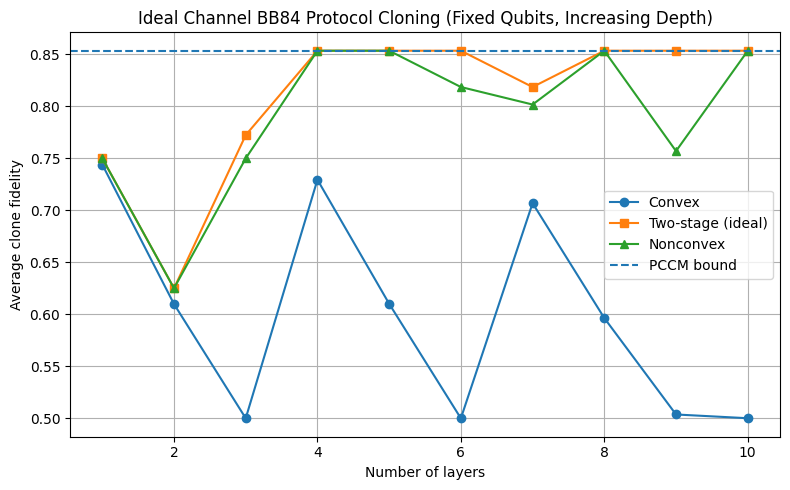

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.read_csv("bb84_fixed_qubits_varying_layers.csv")

plt.figure(figsize=(8, 5))

plt.plot(summary["Layers"], summary["Convex (ideal)"],
         marker="o", label="Convex")
plt.plot(summary["Layers"], summary["Two-stage (ideal)"],
         marker="s", label="Two-stage (ideal)")
plt.plot(summary["Layers"], summary["Nonconvex (ideal)"],
         marker="^", label="Nonconvex")

plt.axhline(pccm_fidelity(), linestyle="--", label="PCCM bound")

plt.xlabel("Number of layers")
plt.ylabel("Average clone fidelity")
plt.title("Ideal Channel BB84 Protocol Cloning (Fixed Qubits, Increasing Depth)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


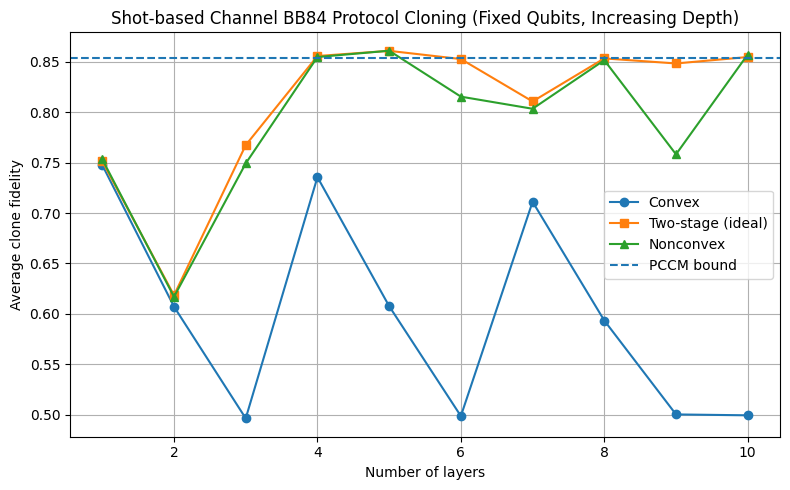

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.read_csv("bb84_fixed_qubits_varying_layers.csv")

plt.figure(figsize=(8, 5))

plt.plot(summary["Layers"], summary["Convex (shots)"],
         marker="o", label="Convex")
plt.plot(summary["Layers"], summary["Two-stage (shots)"],
         marker="s", label="Two-stage (ideal)")
plt.plot(summary["Layers"], summary["Nonconvex (shots)"],
         marker="^", label="Nonconvex")

plt.axhline(pccm_fidelity(), linestyle="--", label="PCCM bound")

plt.xlabel("Number of layers")
plt.ylabel("Average clone fidelity")
plt.title("Shot-based Channel BB84 Protocol Cloning (Fixed Qubits, Increasing Depth)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


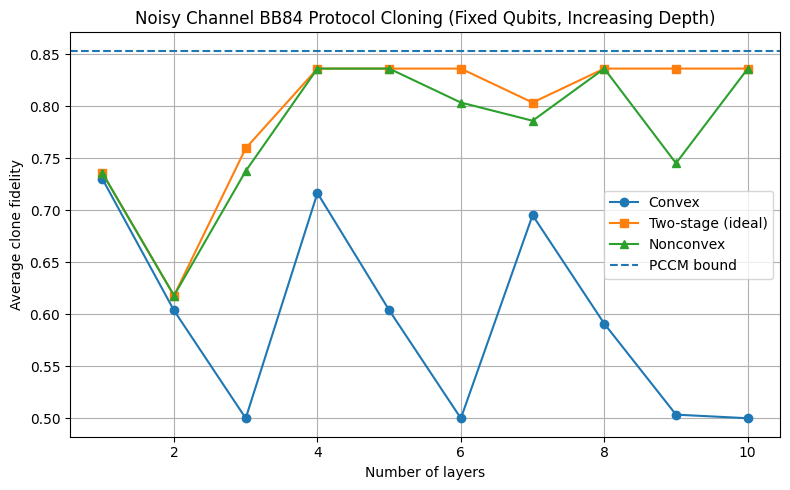

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.read_csv("bb84_fixed_qubits_varying_layers.csv")

plt.figure(figsize=(8, 5))

plt.plot(summary["Layers"], summary["Convex (noisy)"],
         marker="o", label="Convex")
plt.plot(summary["Layers"], summary["Two-stage (noisy)"],
         marker="s", label="Two-stage (ideal)")
plt.plot(summary["Layers"], summary["Nonconvex (noisy)"],
         marker="^", label="Nonconvex")

plt.axhline(pccm_fidelity(), linestyle="--", label="PCCM bound")

plt.xlabel("Number of layers")
plt.ylabel("Average clone fidelity")
plt.title("Noisy Channel BB84 Protocol Cloning (Fixed Qubits, Increasing Depth)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()